In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


## Question 1.1 — Data Preparation

In [3]:
# Loading the dataset
df = pd.read_csv('tech_roles_trends.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (262, 4)

Column names: ['Week', 'Data Analyst', 'Software Engineer', 'Cybersecurity Specialist']

First few rows:


,Week,Data Analyst,Software Engineer,Cybersecurity Specialist
0,4/21/2019,55,55,18
1,4/28/2019,52,50,16
2,5/5/2019,56,56,17
3,5/12/2019,56,61,18
4,5/19/2019,57,56,17


In [4]:
# Checking for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values per column:
Week                        0
Data Analyst                0
Software Engineer           0
Cybersecurity Specialist    0
dtype: int64

Duplicate rows: 0

Data types:
Week                        object
Data Analyst                 int64
Software Engineer            int64
Cybersecurity Specialist     int64
dtype: object


In [5]:
# Converting Week column to datetime and setting it as the index
df['Week'] = pd.to_datetime(df['Week'])
df.set_index('Week', inplace=True)
df.sort_index(inplace=True)

print(" Time index set successfully!")
print("\nDate range:", df.index.min(), "to", df.index.max())
print("Total weeks:", len(df))
print("\nFirst few rows:")
df.head()

 Time index set successfully!

Date range: 2019-04-21 00:00:00 to 2024-04-21 00:00:00
Total weeks: 262

First few rows:


,Data Analyst,Software Engineer,Cybersecurity Specialist
Week,,,
2019-04-21,55,55,18
2019-04-28,52,50,16
2019-05-05,56,56,17
2019-05-12,56,61,18
2019-05-19,57,56,17


## Question 1.2 — Exploratory Analysis

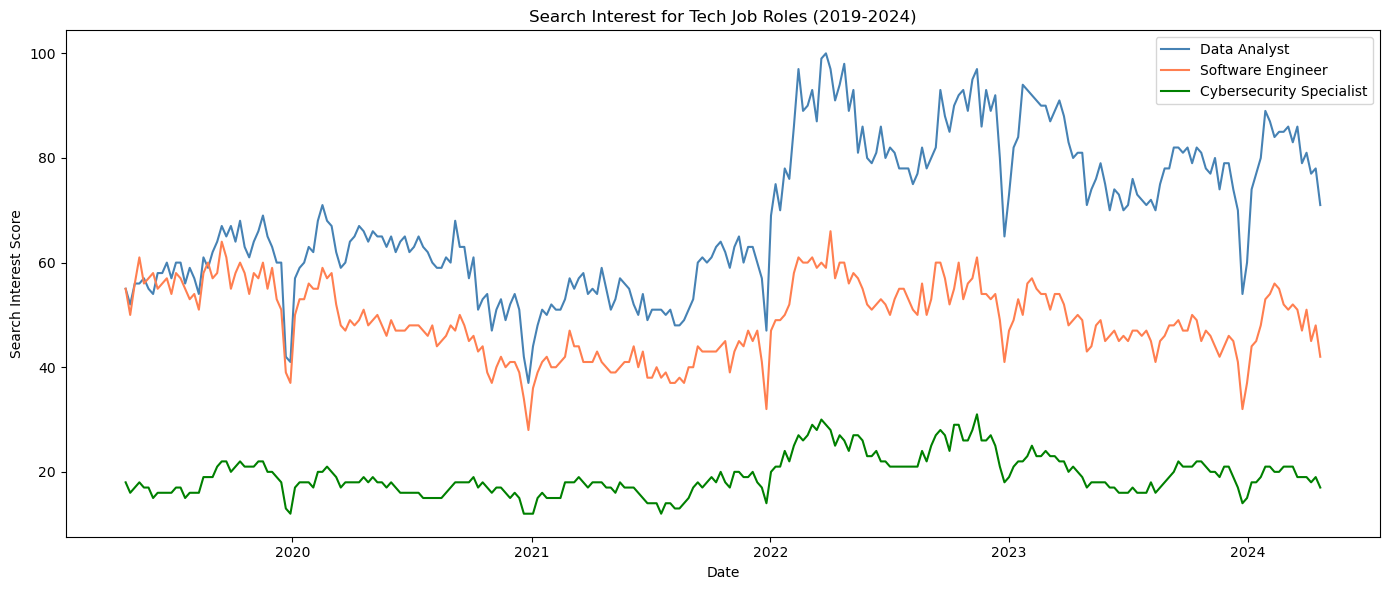

In [6]:
# Plotting all three job roles over time to see thee overall trends
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Data Analyst'], label='Data Analyst', color='steelblue')
plt.plot(df.index, df['Software Engineer'], label='Software Engineer', color='coral')
plt.plot(df.index, df['Cybersecurity Specialist'], label='Cybersecurity Specialist', color='green')
plt.title('Search Interest for Tech Job Roles (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Search Interest Score')
plt.legend()
plt.tight_layout()
plt.show()

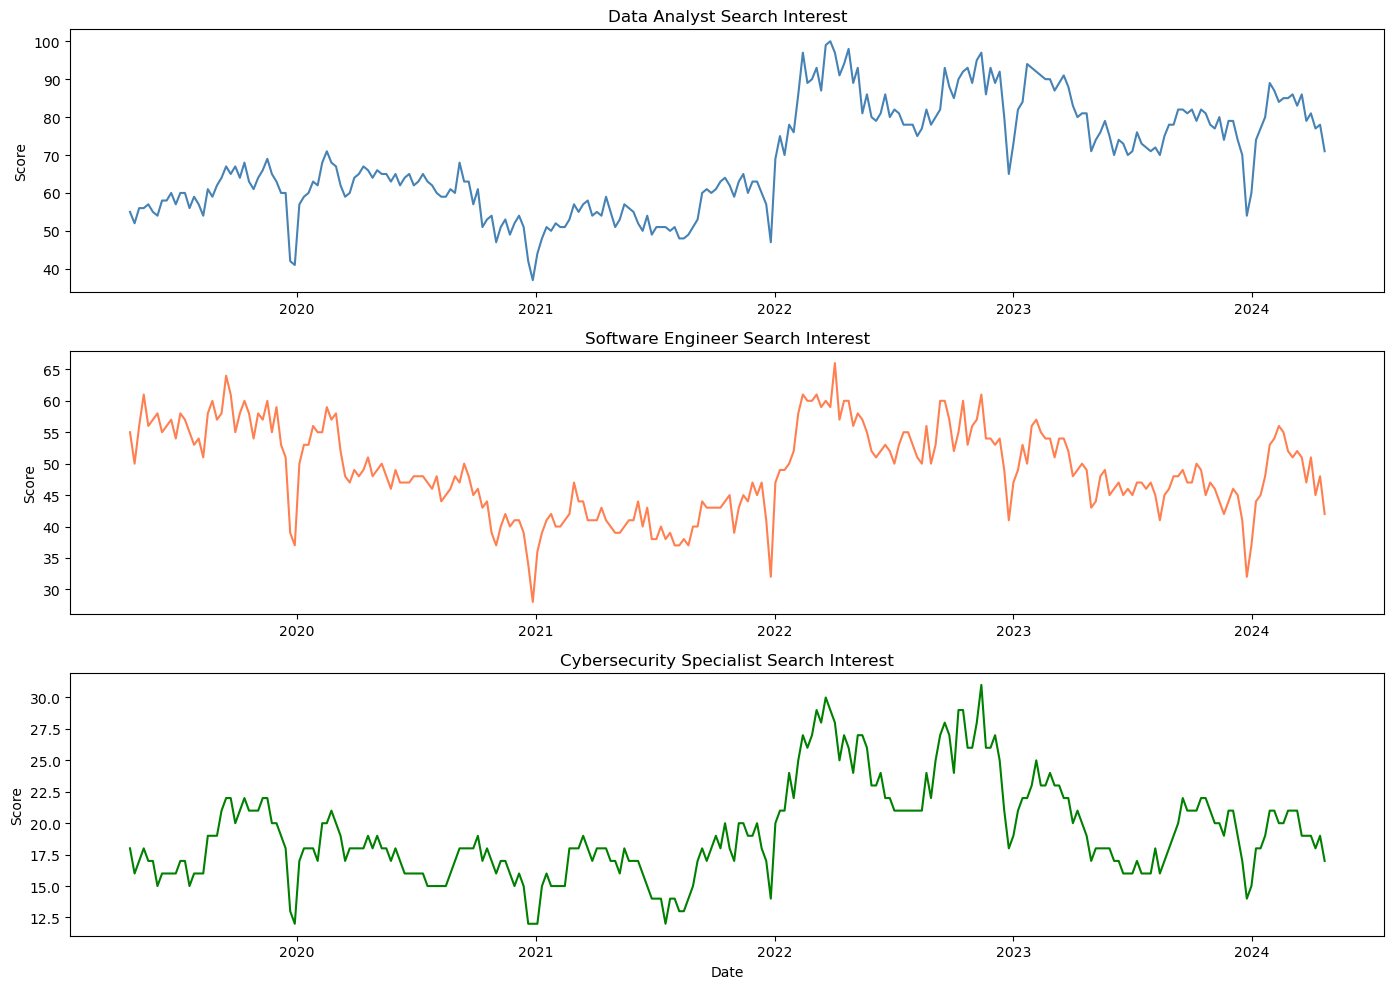

In [7]:
# Plotting each job role separately for a clearer view
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df.index, df['Data Analyst'], color='steelblue')
axes[0].set_title('Data Analyst Search Interest')
axes[0].set_ylabel('Score')

axes[1].plot(df.index, df['Software Engineer'], color='coral')
axes[1].set_title('Software Engineer Search Interest')
axes[1].set_ylabel('Score')

axes[2].plot(df.index, df['Cybersecurity Specialist'], color='green')
axes[2].set_title('Cybersecurity Specialist Search Interest')
axes[2].set_ylabel('Score')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [8]:
# Summary statistics for each job role
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
       Data Analyst  Software Engineer  Cybersecurity Specialist
count    262.000000         262.000000                262.000000
mean      68.965649          48.851145                 19.290076
std       14.073519           6.925768                  3.805599
min       37.000000          28.000000                 12.000000
25%       58.000000          44.000000                 17.000000
50%       65.500000          48.000000                 18.000000
75%       80.000000          54.000000                 21.000000
max      100.000000          66.000000                 31.000000


### Now im going to do the decomposition

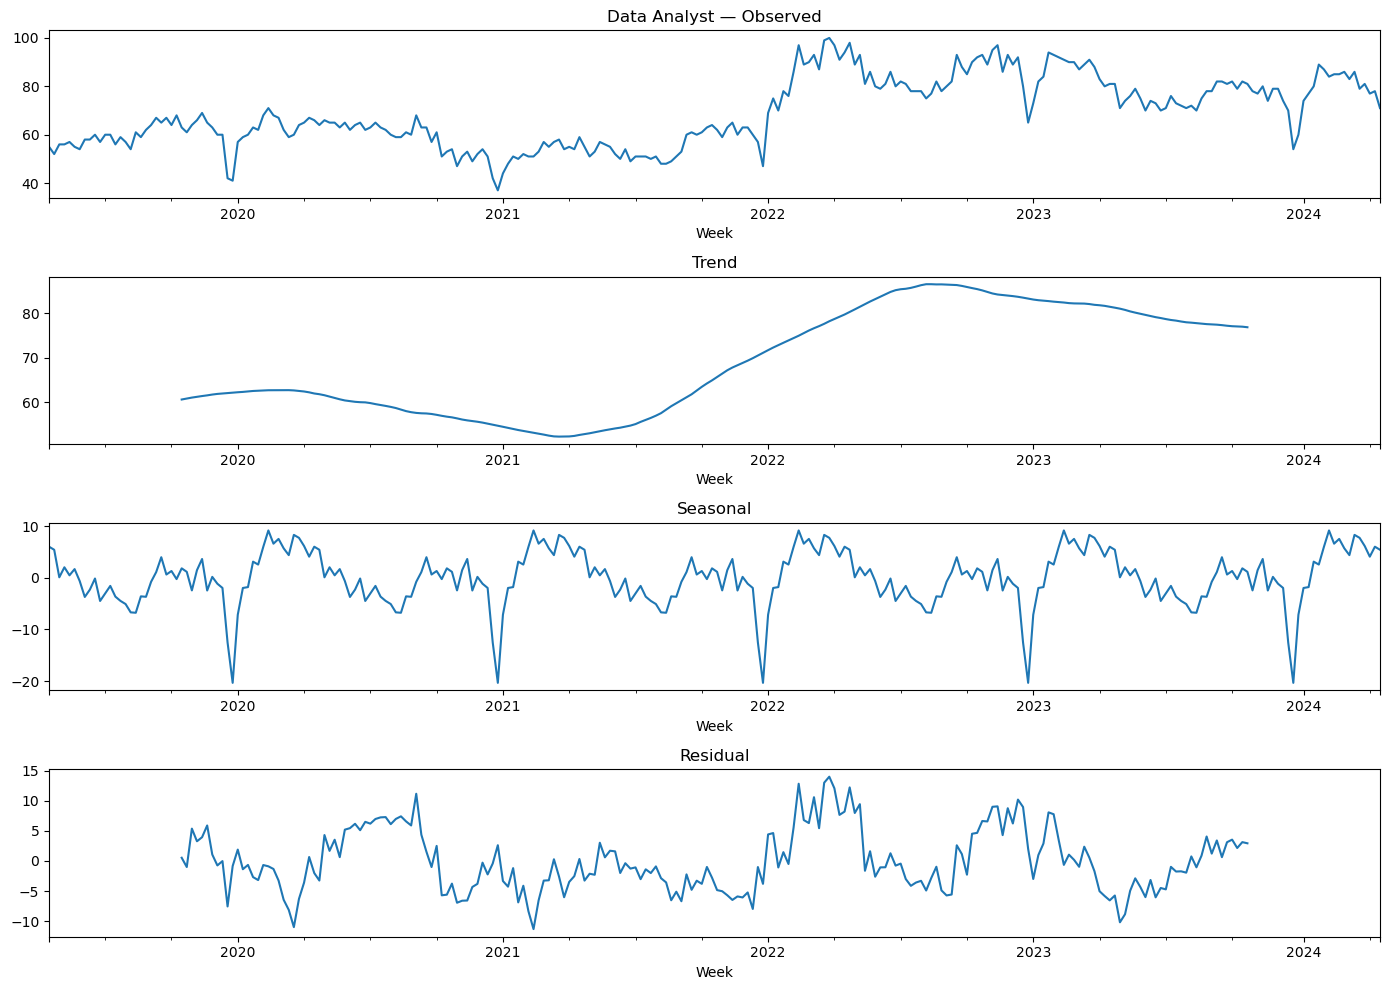

In [9]:
# Decomposing Data Analyst time series into trend, seasonal and residual
decomp_da = seasonal_decompose(df['Data Analyst'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp_da.observed.plot(ax=axes[0], title='Data Analyst — Observed')
decomp_da.trend.plot(ax=axes[1], title='Trend')
decomp_da.seasonal.plot(ax=axes[2], title='Seasonal')
decomp_da.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

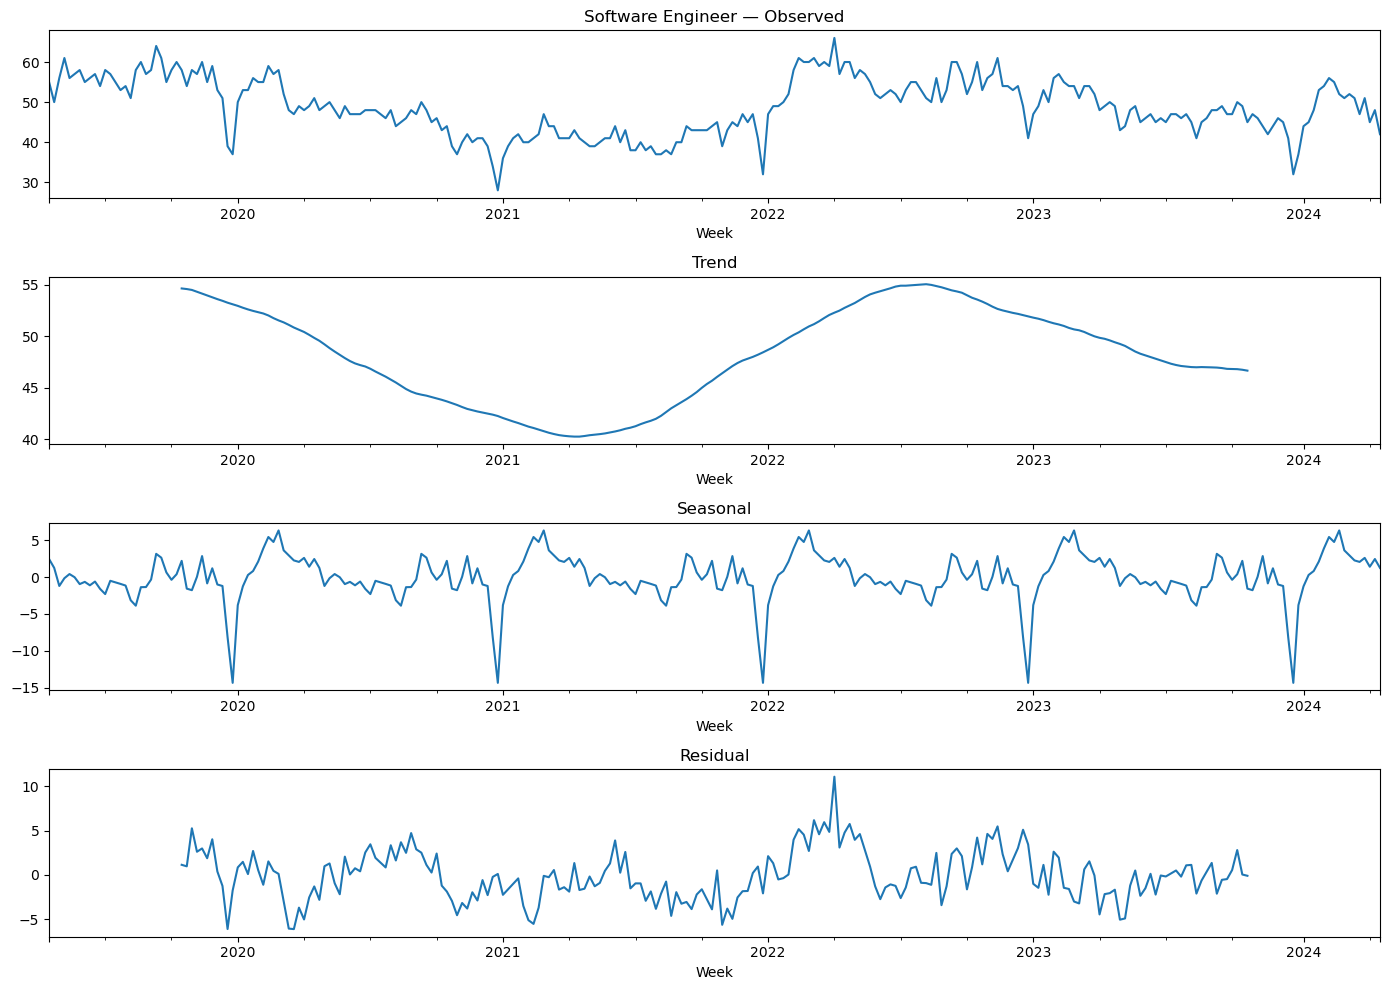

In [10]:
# Decomposing Software Engineer time series
decomp_se = seasonal_decompose(df['Software Engineer'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp_se.observed.plot(ax=axes[0], title='Software Engineer — Observed')
decomp_se.trend.plot(ax=axes[1], title='Trend')
decomp_se.seasonal.plot(ax=axes[2], title='Seasonal')
decomp_se.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

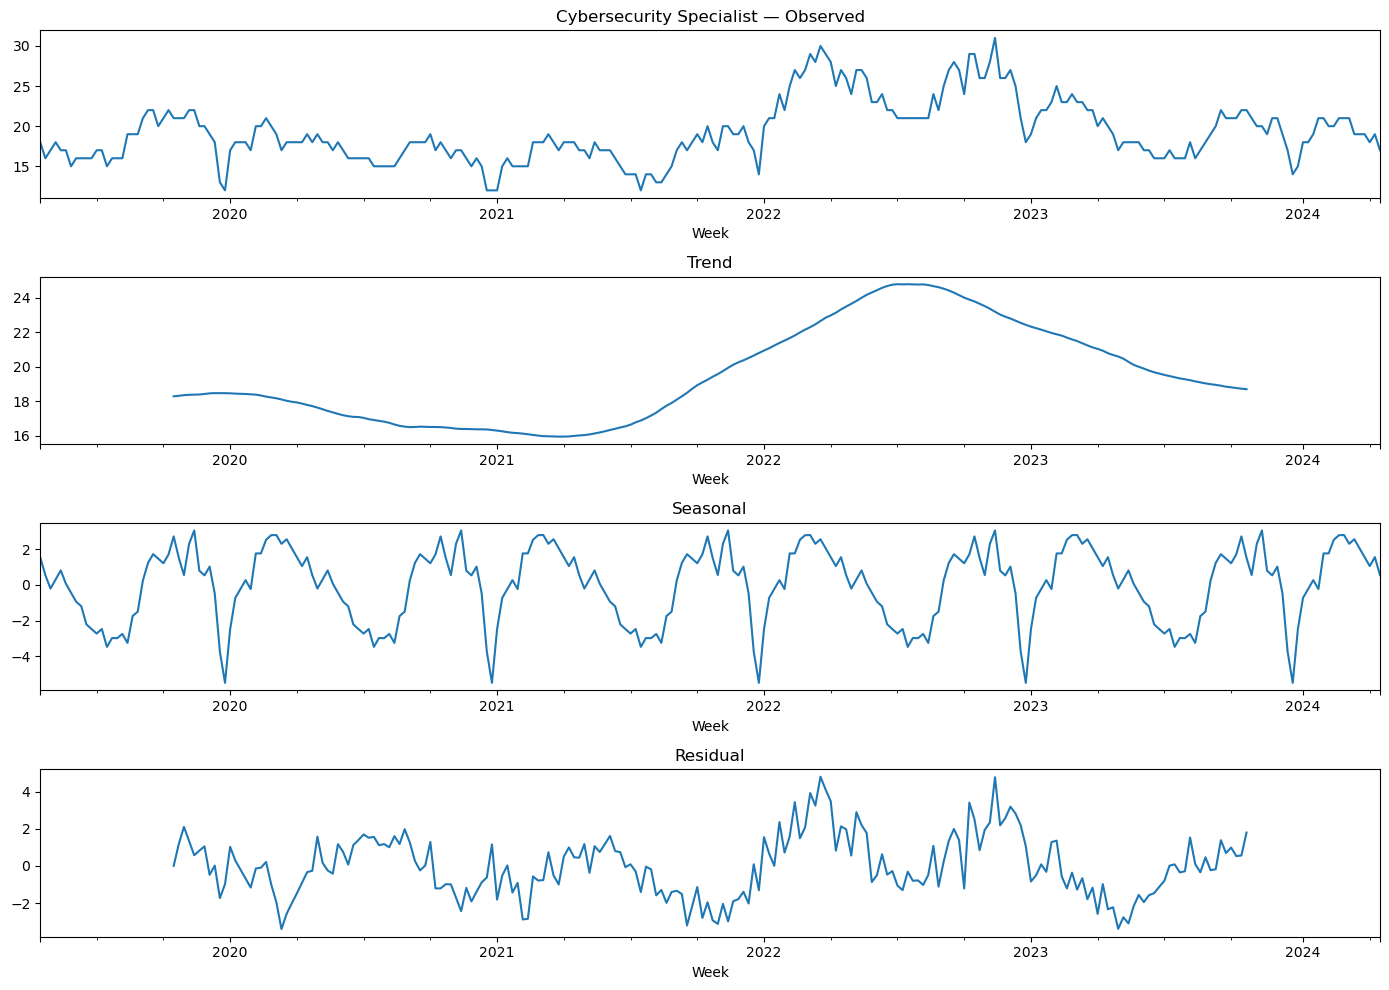

In [11]:
# Decomposing Cybersecurity Specialist time series
decomp_cs = seasonal_decompose(df['Cybersecurity Specialist'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp_cs.observed.plot(ax=axes[0], title='Cybersecurity Specialist — Observed')
decomp_cs.trend.plot(ax=axes[1], title='Trend')
decomp_cs.seasonal.plot(ax=axes[2], title='Seasonal')
decomp_cs.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

## Question 1.3 — Stationarity Testing

In [12]:
# Testing stationarity using ADF test for all 3 job roles
# ADF test: if p-value < 0.05 the series is stationary

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n=== ADF Test: {name} ===")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"P-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("Result: STATIONARY ")
    else:
        print("Result: NOT STATIONARYY — needs transformation")

adf_test(df['Data Analyst'], 'Data Analyst')
adf_test(df['Software Engineer'], 'Software Engineer')
adf_test(df['Cybersecurity Specialist'], 'Cybersecurity Specialist')


=== ADF Test: Data Analyst ===
ADF Statistic: -2.2794
P-value: 0.1787
Result: NOT STATIONARYY — needs transformation

=== ADF Test: Software Engineer ===
ADF Statistic: -3.0600
P-value: 0.0297
Result: STATIONARY 

=== ADF Test: Cybersecurity Specialist ===
ADF Statistic: -2.8753
P-value: 0.0483
Result: STATIONARY 



=== ADF Test: Data Analyst (After Differencing) ===
ADF Statistic: -13.6396
P-value: 0.0000
Result: STATIONARY 


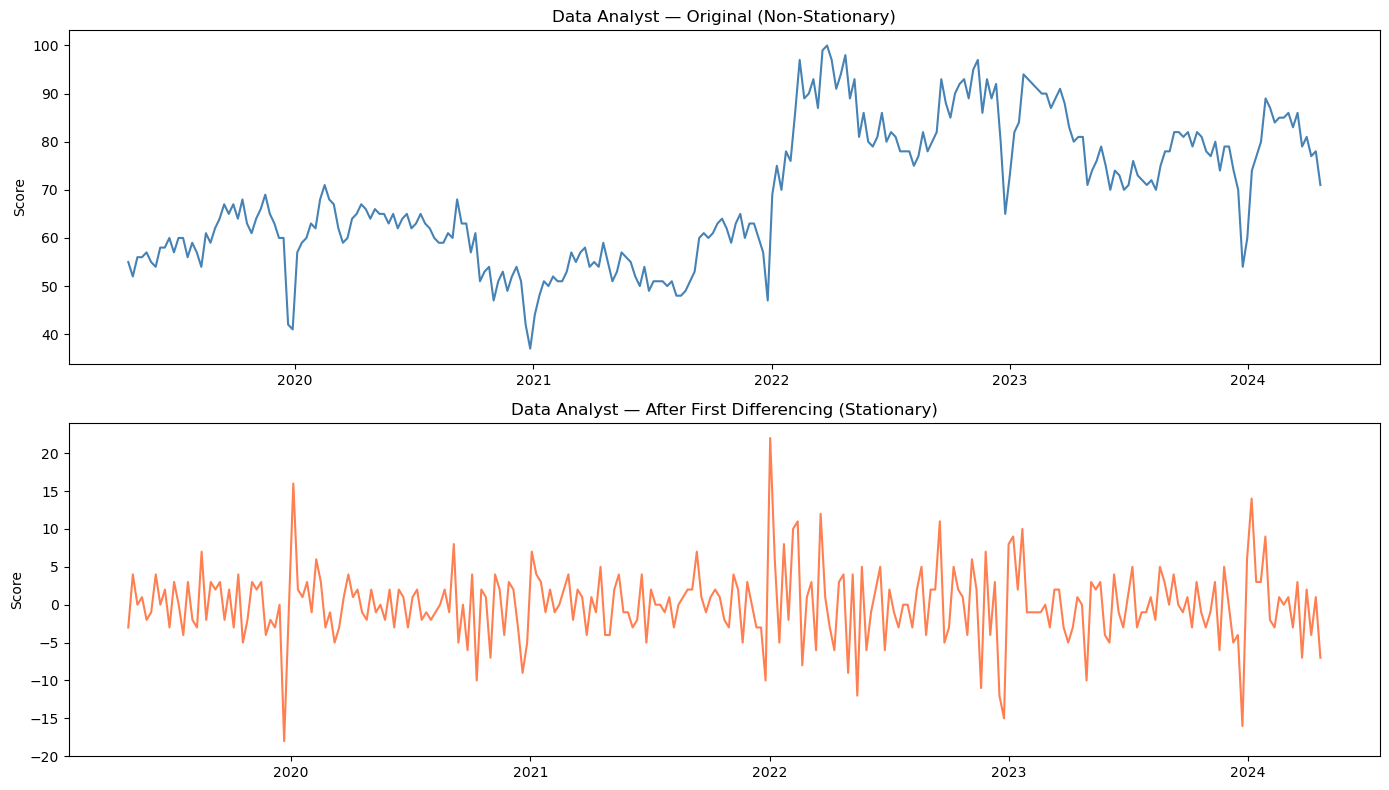

In [13]:
# Data Analyst is not stationary so we apply first differencing
df['Data Analyst Diff'] = df['Data Analyst'].diff()

# Testing stationarity again after differencing
adf_test(df['Data Analyst Diff'], 'Data Analyst (After Differencing)')

# Plotting original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df.index, df['Data Analyst'], color='steelblue')
axes[0].set_title('Data Analyst — Original (Non-Stationary)')
axes[0].set_ylabel('Score')

axes[1].plot(df.index, df['Data Analyst Diff'], color='coral')
axes[1].set_title('Data Analyst — After First Differencing (Stationary)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()